<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/scratchpad_bo_or_not.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
%%capture
pip install fiftyone==1.8.0

In [5]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


## Downloading data from Kaggle

In [7]:
import os
from google.colab import userdata
import kagglehub

# This is set up as an environment variable, it's alive in memory
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# to download the data, we specify the name of the user who published it and the name of the dataset
download_path = kagglehub.dataset_download('andandand/presidential-dog')

Using Colab cache for faster access to the 'presidential-dog' dataset.


In [8]:
download_path

'/kaggle/input/presidential-dog'

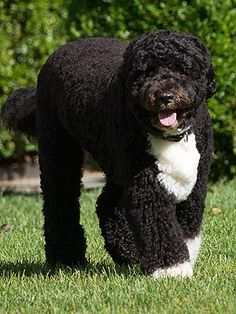

In [9]:
from PIL import Image
pil_imag = Image.open('/kaggle/input/presidential-dog/presidential_dog/train/bo/bo_1.jpg')
pil_imag

In [14]:
from torchvision.models import VGG16_Weights
pretrained_weights = VGG16_Weights.IMAGENET1K_V1
dir(pretrained_weights)

['__class__',
 '__doc__',
 '__eq__',
 '__hash__',
 '__module__',
 'get_state_dict',
 'meta',
 'name',
 'transforms',
 'url',
 'value',
 'verify']

In [11]:
original_transformation = pretrained_weights.transforms()
original_transformation

NameError: name 'pretrained_weights' is not defined

In [12]:
imag_tensor_imagenet_scaled = original_transformation(pil_imag)
imag_tensor_imagenet_scaled.shape

NameError: name 'original_transformation' is not defined

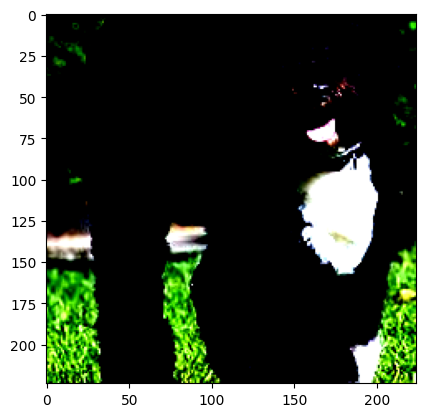

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(imag_tensor_imagenet_scaled.permute(1, 2, 0))


In [ ]:
pretrained_weights.meta

{'min_size': (32, 32),
 'categories': ['tench',
  'goldfish',
  'great white shark',
  'tiger shark',
  'hammerhead',
  'electric ray',
  'stingray',
  'cock',
  'hen',
  'ostrich',
  'brambling',
  'goldfinch',
  'house finch',
  'junco',
  'indigo bunting',
  'robin',
  'bulbul',
  'jay',
  'magpie',
  'chickadee',
  'water ouzel',
  'kite',
  'bald eagle',
  'vulture',
  'great grey owl',
  'European fire salamander',
  'common newt',
  'eft',
  'spotted salamander',
  'axolotl',
  'bullfrog',
  'tree frog',
  'tailed frog',
  'loggerhead',
  'leatherback turtle',
  'mud turtle',
  'terrapin',
  'box turtle',
  'banded gecko',
  'common iguana',
  'American chameleon',
  'whiptail',
  'agama',
  'frilled lizard',
  'alligator lizard',
  'Gila monster',
  'green lizard',
  'African chameleon',
  'Komodo dragon',
  'African crocodile',
  'American alligator',
  'triceratops',
  'thunder snake',
  'ringneck snake',
  'hognose snake',
  'green snake',
  'king snake',
  'garter snake',
 

In [ ]:
from torchvision.models import vgg16, VGG16_Weights

# Loading a pre-trained VGG16 model
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Here we inspect the first layer of features
first_layer = model.features[0]
first_layer

Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [ ]:
first_layer.weight

Parameter containing:
tensor([[[[-5.5373e-01,  1.4270e-01,  5.2896e-01],
          [-5.8312e-01,  3.5655e-01,  7.6566e-01],
          [-6.9022e-01, -4.8019e-02,  4.8409e-01]],

         [[ 1.7548e-01,  9.8630e-03, -8.1413e-02],
          [ 4.4089e-02, -7.0323e-02, -2.6035e-01],
          [ 1.3239e-01, -1.7279e-01, -1.3226e-01]],

         [[ 3.1303e-01, -1.6591e-01, -4.2752e-01],
          [ 4.7519e-01, -8.2677e-02, -4.8700e-01],
          [ 6.3203e-01,  1.9308e-02, -2.7753e-01]]],


        [[[ 2.3254e-01,  1.2666e-01,  1.8605e-01],
          [-4.2805e-01, -2.4349e-01,  2.4628e-01],
          [-2.5066e-01,  1.4177e-01, -5.4864e-03]],

         [[-1.4076e-01, -2.1903e-01,  1.5041e-01],
          [-8.4127e-01, -3.5176e-01,  5.6398e-01],
          [-2.4194e-01,  5.1928e-01,  5.3915e-01]],

         [[-3.1432e-01, -3.7048e-01, -1.3094e-01],
          [-4.7144e-01, -1.5503e-01,  3.4589e-01],
          [ 5.4384e-02,  5.8683e-01,  4.9580e-01]]],


        [[[ 1.7715e-01,  5.2149e-01,  9.8740

In [3]:
# Why doesn't this work?
#first_layer(pil_imag)
output_first_convolutions = first_layer(imag_tensor_imagenet_scaled)
output_first_convolutions.shape

NameError: name 'first_layer' is not defined

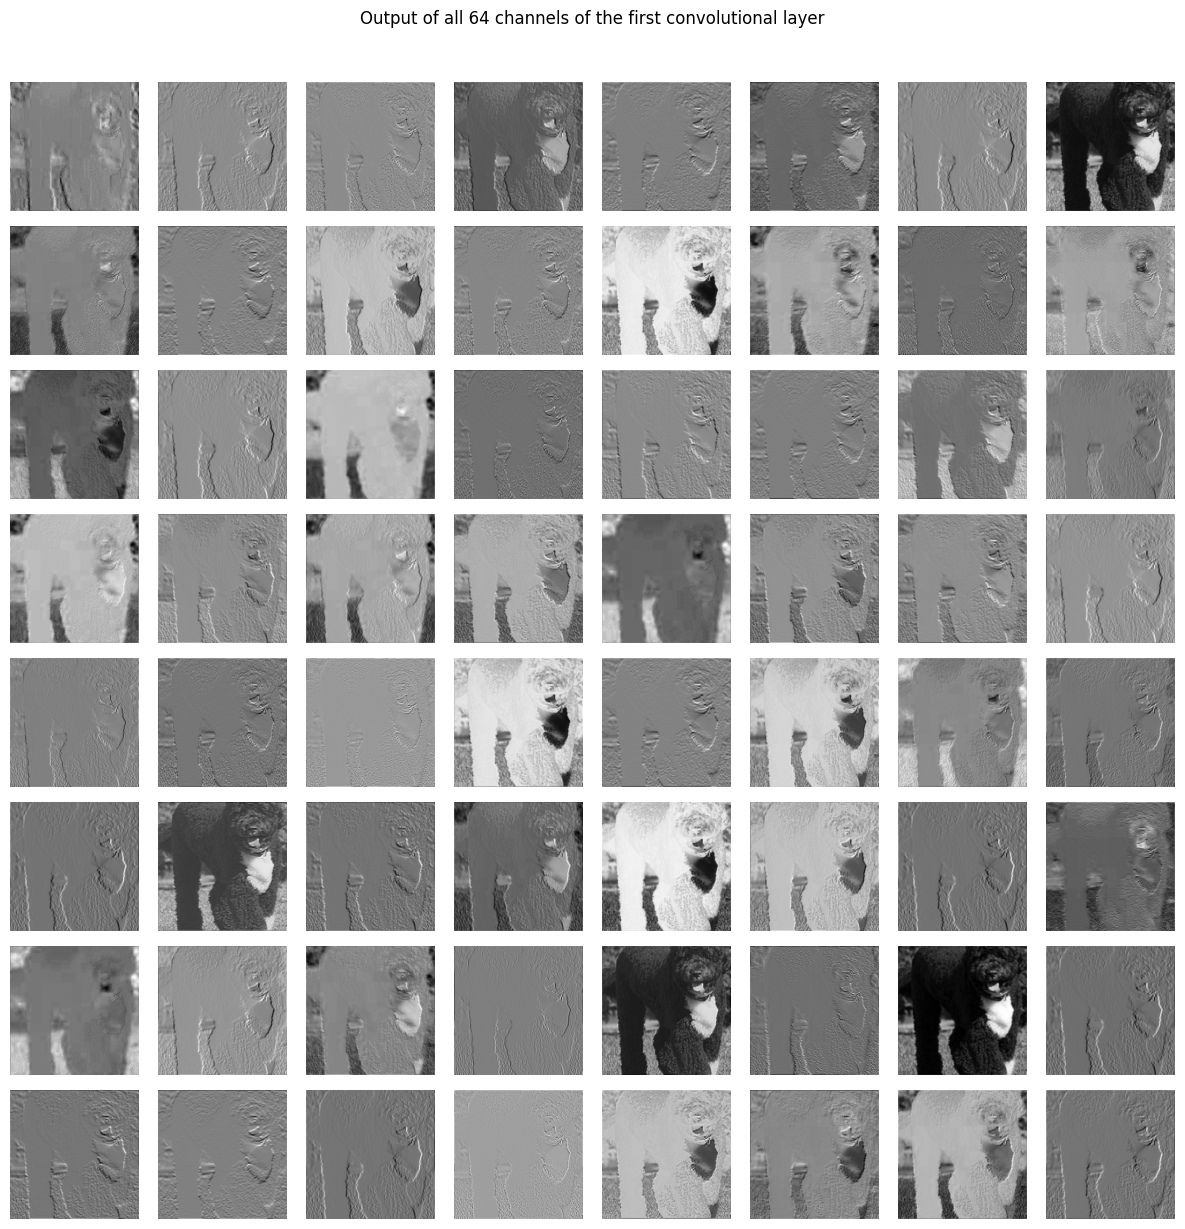

In [ ]:
num_channels = output_first_convolutions.shape[0]
fig, axes = plt.subplots(8, 8, figsize=(12, 12))

for i in range(num_channels):
    row = i // 8
    col = i % 8
    axes[row, col].imshow(output_first_convolutions[i, :, :].detach().numpy(), cmap='gray')
    axes[row, col].axis('off')

plt.suptitle('Output of all 64 channels of the first convolutional layer', y=1.02)
plt.tight_layout()
plt.show()

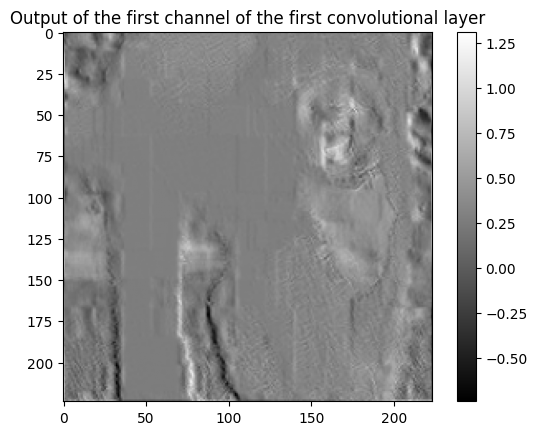

In [ ]:
plt.imshow(output_first_convolutions[0, :, :].detach().numpy(), cmap='gray')
plt.title('Output of the first channel of the first convolutional layer')
plt.colorbar()
plt.show()